# LR02 - Linear Regression using insurance.csv
Name : Sabhyam Mishra
Class : MCA AI & Data Science
Roll No.: KH.EN.P2MCA25151

## Dataset Description
The dataset used is insurance.csv, which contains 1338 samples and 7 columns.

Input features (independent variables):
- age
- sex
- bmi
- children
- smoker
- region

Target variable (dependent variable):
- charges

Categorical Features:
- age
- smoker
- region

In [9]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [10]:
df = pd.read_csv('insurance.csv')
print('Shape:', df.shape)
df.head()

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [12]:
print('Missing values by column:')
df.isna().sum()

Missing values by column:


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [13]:
dataset = df.copy()
dataset = pd.get_dummies(dataset, drop_first=True)
dataset.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [14]:
X = dataset.drop('charges', axis=1)
y = dataset['charges']

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train shape:', train_X.shape)
print('Test shape:', test_X.shape)

Train shape: (1070, 8)
Test shape: (268, 8)


In [15]:
lin_reg = LinearRegression()
lin_reg.fit(train_X, train_y)

lin_train_pred = lin_reg.predict(train_X)
lin_test_pred = lin_reg.predict(test_X)

print('Linear Regression Train R2:', r2_score(train_y, lin_train_pred))
print('Linear Regression Test R2 :', r2_score(test_y, lin_test_pred))
print('Linear Regression Test RMSE:', np.sqrt(mean_squared_error(test_y, lin_test_pred)))
print('Linear Regression Test MAE :', mean_absolute_error(test_y, lin_test_pred))

Linear Regression Train R2: 0.7417255854683333
Linear Regression Test R2 : 0.7835929767120722
Linear Regression Test RMSE: 5796.284659276274
Linear Regression Test MAE : 4181.194473753654


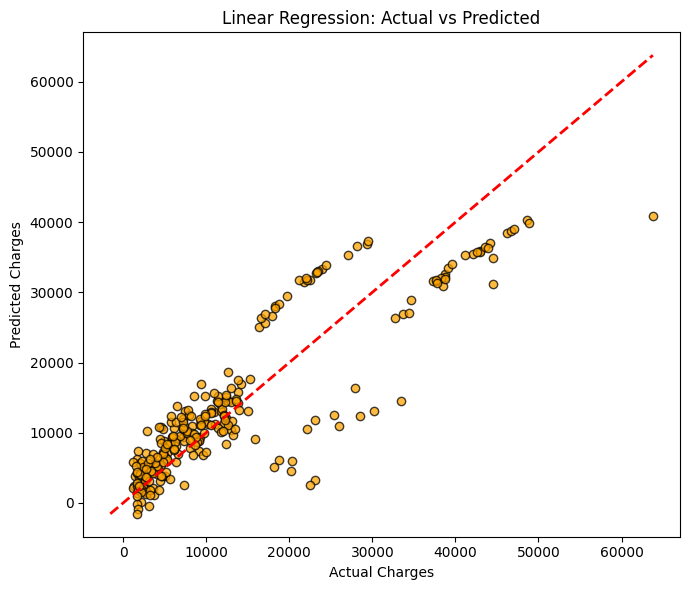

In [16]:
plt.figure(figsize=(7, 6))
plt.scatter(test_y, lin_test_pred, c='orange', edgecolors='black', alpha=0.75)
line_min = min(test_y.min(), lin_test_pred.min())
line_max = max(test_y.max(), lin_test_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2)
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

In [17]:

predictions_df = test_X.copy()
predictions_df['Actual'] = test_y.values
predictions_df['Predicted'] = lin_test_pred
predictions_df['Error'] = predictions_df['Actual'] - predictions_df['Predicted']

predictions_df.to_csv('lr02_predictions.csv', index=False)
print('Predictions saved to lr02_predictions.csv')
predictions_df.head()

Predictions saved to lr02_predictions.csv


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,Actual,Predicted,Error
764,45,25.175,2,False,False,False,False,False,9095.06825,8969.550274,125.517976
887,36,30.020,0,False,False,True,False,False,5272.17580,7068.747443,-1796.571643
890,64,26.885,0,False,True,True,False,False,29330.98315,36858.410912,-7527.427762
1293,46,25.745,3,True,False,True,False,False,9301.89355,9454.678501,-152.784951
259,19,31.920,0,True,True,True,False,False,33750.29180,26973.173457,6777.118343


In [18]:
lasso_reg = Lasso(alpha=0.1, max_iter=10000)
lasso_reg.fit(train_X, train_y)

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(train_X, train_y)

lasso_test_pred = lasso_reg.predict(test_X)
ridge_test_pred = ridge_reg.predict(test_X)

In [19]:
comparison_df = pd.DataFrame({
    'Model': ['LinearRegression', 'Lasso (L1)', 'Ridge (L2)'],
    'Train_R2': [
        lin_reg.score(train_X, train_y),
        lasso_reg.score(train_X, train_y),
        ridge_reg.score(train_X, train_y)
    ],
    'Test_R2': [
        lin_reg.score(test_X, test_y),
        lasso_reg.score(test_X, test_y),
        ridge_reg.score(test_X, test_y)
    ],
    'Test_RMSE': [
        np.sqrt(mean_squared_error(test_y, lin_test_pred)),
        np.sqrt(mean_squared_error(test_y, lasso_test_pred)),
        np.sqrt(mean_squared_error(test_y, ridge_test_pred))
    ]
})
comparison_df

,Model,Train_R2,Test_R2,Test_RMSE
0,LinearRegression,0.741726,0.783593,5796.284659
1,Lasso (L1),0.741726,0.783587,5796.358344
2,Ridge (L2),0.741705,0.783283,5800.434216


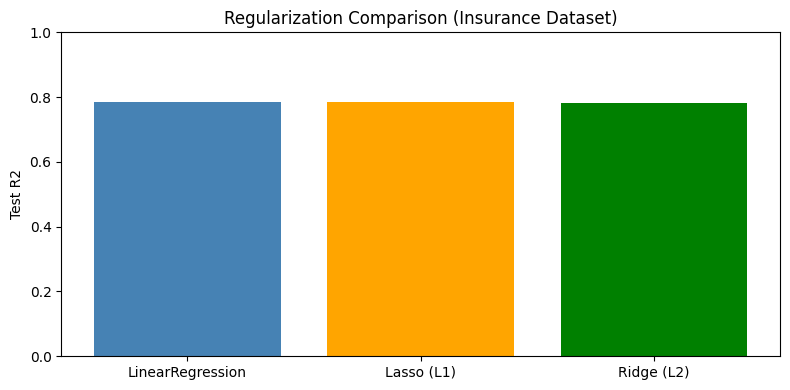

In [20]:
plt.figure(figsize=(8, 4))
plt.bar(comparison_df['Model'], comparison_df['Test_R2'], color=['steelblue', 'orange', 'green'])
plt.ylabel('Test R2')
plt.title('Regularization Comparison (Insurance Dataset)')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()